In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
cigarette = pd.read_csv("przyk/Cigarette10.csv", sep=';')
guns = pd.read_csv("przyk/Guns10.csv", sep=';')


# Wyświetlenie kolumn i pierwszych 5 wierszy
print("Cigarette columns:", cigarette.columns.tolist())
print(cigarette.head(), '\n')

print("Guns columns:", guns.columns.tolist())
print(guns.head())

Cigarette columns: ['rownames', 'state', 'year', 'cpi', 'pop', 'packpc', 'income', 'tax', 'avgprs', 'taxs']
   rownames state  year    cpi       pop      packpc     income        tax  \
0         1    AL  1985  1.076   3973000  116.486282   46014968  32.500004   
1         2    AR  1985  1.076   2327000  128.534592   26210736  37.000000   
2         3    AZ  1985  1.076   3184000  104.522614   43956936  31.000000   
3         4    CA  1985  1.076  26444000  100.363037  447102816  26.000000   
4         5    CO  1985  1.076   3209000  112.963539   49466672  31.000000   

       avgprs       taxs  
0  102.181671  33.348335  
1  101.474998  37.000000  
2  108.578751  36.170418  
3  107.837341  32.104000  
4   94.266663  31.000000   

Guns columns: ['rownames', 'year', 'violent', 'murder', 'robbery', 'prisoners', 'afam', 'cauc', 'male', 'population', 'income', 'density', 'state', 'law']
   rownames  year  violent  murder  robbery  prisoners      afam      cauc  \
0         9  1985    457.5

# Histogramy

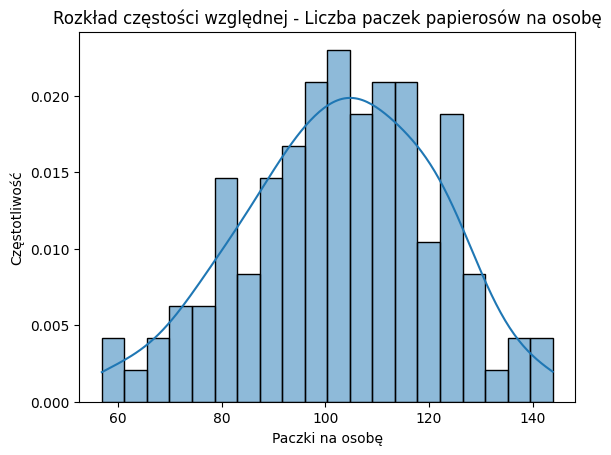

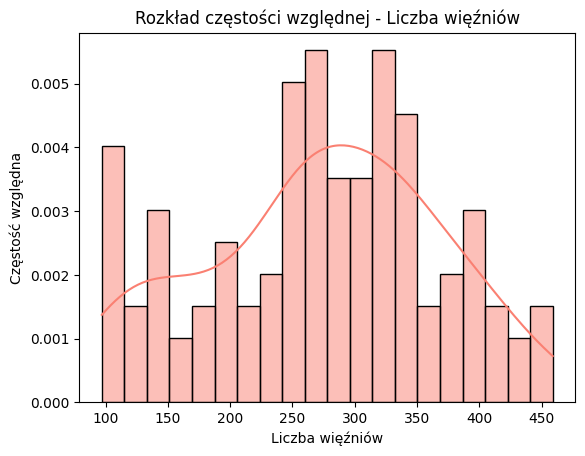

In [5]:
sns.histplot(cigarette['packpc'], bins=20, kde=True, stat='density')
plt.title("Rozkład częstości względnej - Liczba paczek papierosów na osobę")
plt.xlabel("Paczki na osobę")
plt.ylabel("Częstotliwość")
plt.show()

sns.histplot(guns['prisoners'], bins=20, kde=True, stat='density', color='salmon')
plt.title("Rozkład częstości względnej - Liczba więźniów")
plt.xlabel("Liczba więźniów")
plt.ylabel("Częstość względna")
plt.show()


# Wykresy

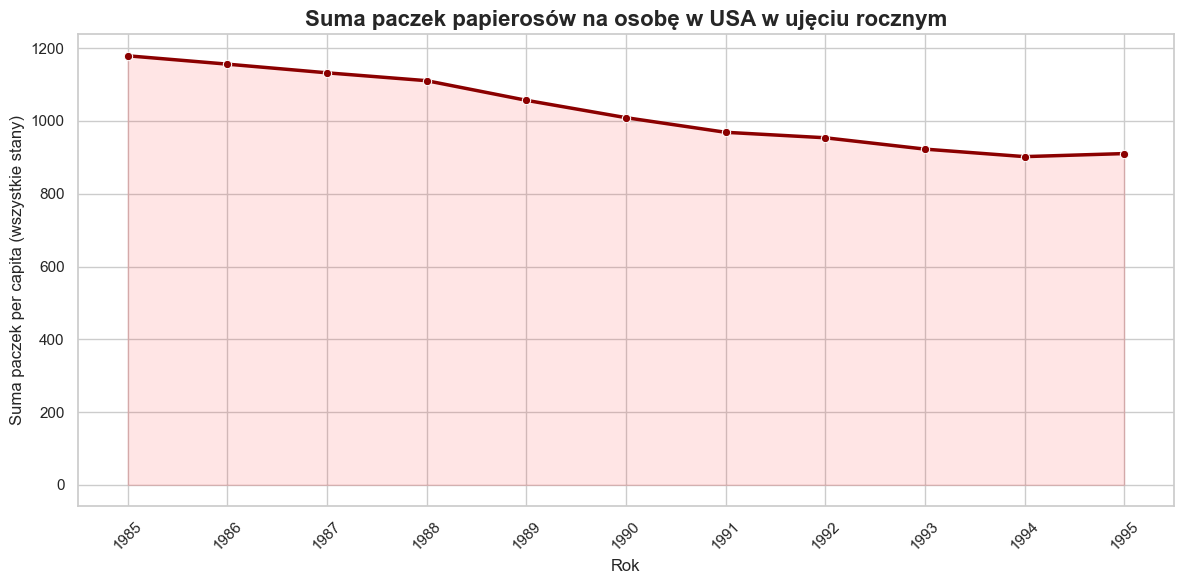

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
cigarette = pd.read_csv("przyk/Cigarette10.csv", sep=';')

# Konwersja typu 'year' na liczbowy (jeśli to nie int)
cigarette['year'] = pd.to_numeric(cigarette['year'], errors='coerce')

# Grupowanie danych
pack_per_year = cigarette.groupby('year')['packpc'].sum().reset_index()

# Styl wykresu
sns.set_style("whitegrid")

# Rysowanie wykresu
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=pack_per_year,
    x='year',
    y='packpc',
    marker='o',
    color='darkred',
    linewidth=2.5
)

# Wypełnienie pod linią
plt.fill_between(pack_per_year['year'], pack_per_year['packpc'], alpha=0.1, color='red')

# Etykiety i tytuł
plt.title('Suma paczek papierosów na osobę w USA w ujęciu rocznym', fontsize=16, weight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Suma paczek per capita (wszystkie stany)', fontsize=12)

# Wymuszenie lat co jeden rok
plt.xticks(ticks=pack_per_year['year'], rotation=45)

plt.tight_layout()
plt.show()


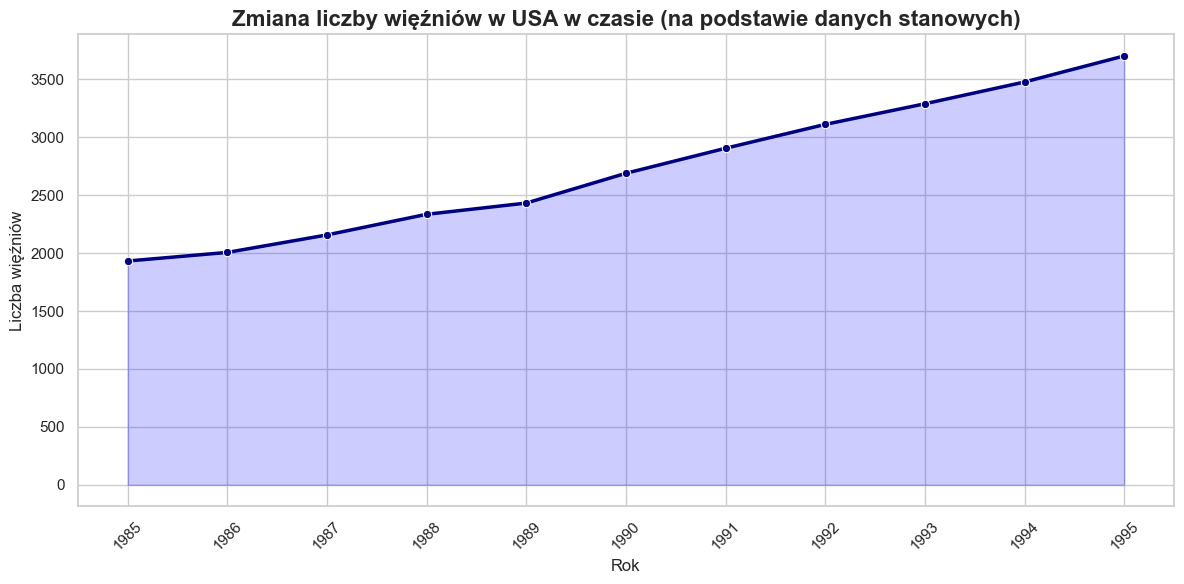

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
guns = pd.read_csv("przyk/Guns10.csv", sep=';')

# Konwersja kolumny 'year' na liczbę
guns['year'] = pd.to_numeric(guns['year'], errors='coerce')

# Grupowanie po roku – suma więźniów (jeśli dane są per stan)
prisoners_per_year = guns.groupby('year')['prisoners'].sum().reset_index()

# Styl wykresu
sns.set_style("whitegrid")

# Rysowanie wykresu
plt.figure(figsize=(12, 6))
sns.lineplot(data=prisoners_per_year, x='year', y='prisoners', marker='o', color='navy', linewidth=2.5)
plt.fill_between(prisoners_per_year['year'], prisoners_per_year['prisoners'], alpha=0.2, color='blue')

# Etykiety i tytuł
plt.title('Zmiana liczby więźniów w USA w czasie (na podstawie danych stanowych)', fontsize=16, weight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Liczba więźniów', fontsize=12)

# Lata co jeden rok
plt.xticks(ticks=prisoners_per_year['year'], rotation=45)

plt.tight_layout()
plt.show()


# Dystrybuanty

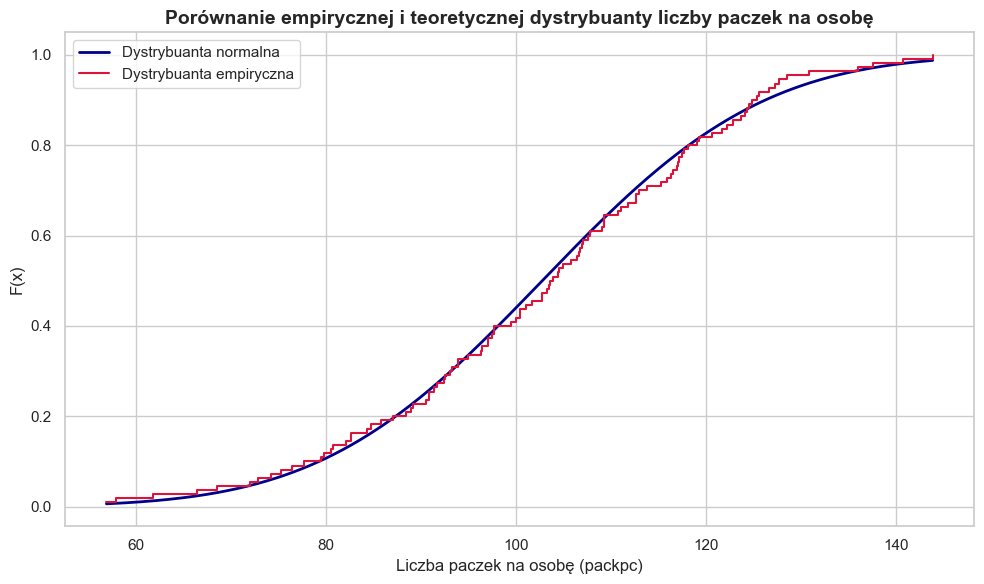

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Wczytanie danych
cigarette = pd.read_csv("przyk/Cigarette10.csv", sep=';')

# Dane: packpc bez braków
packpc = cigarette['packpc'].dropna()

# Parametry rozkładu normalnego
mu, sigma = packpc.mean(), packpc.std()

# Zakres x
x = np.linspace(packpc.min(), packpc.max(), 500)

# Teoretyczna dystrybuanta normalna
cdf_normal = norm.cdf(x, loc=mu, scale=sigma)

# Empiryczna dystrybuanta (ECDF)
sorted_packpc = np.sort(packpc)
ecdf_y = np.arange(1, len(sorted_packpc) + 1) / len(sorted_packpc)

# Rysowanie wykresu
plt.figure(figsize=(10, 6))

# Teoretyczna dystrybuanta
plt.plot(x, cdf_normal, color='darkblue', linewidth=2, label='Dystrybuanta normalna')

# Empiryczna dystrybuanta
plt.step(sorted_packpc, ecdf_y, where='post', color='crimson', label='Dystrybuanta empiryczna')

# Tytuł i opisy
plt.title('Porównanie empirycznej i teoretycznej dystrybuanty liczby paczek na osobę', fontsize=14, weight='bold')
plt.xlabel('Liczba paczek na osobę (packpc)', fontsize=12)
plt.ylabel('F(x)', fontsize=12)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


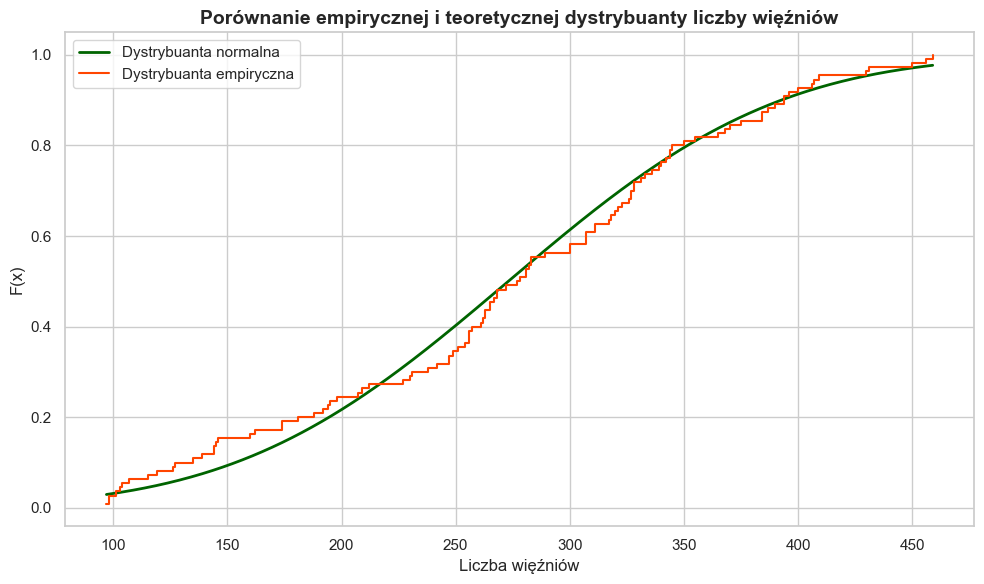

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Wczytanie danych
guns = pd.read_csv("przyk/Guns10.csv", sep=';')

# Dane: liczba więźniów bez braków
prisoners = guns['prisoners'].dropna()

# Parametry rozkładu normalnego
mu, sigma = prisoners.mean(), prisoners.std()

# Zakres x
x = np.linspace(prisoners.min(), prisoners.max(), 500)

# Teoretyczna dystrybuanta normalna
cdf_normal = norm.cdf(x, loc=mu, scale=sigma)

# Empiryczna dystrybuanta
sorted_prisoners = np.sort(prisoners)
ecdf_y = np.arange(1, len(sorted_prisoners) + 1) / len(sorted_prisoners)

# Rysowanie wykresu
plt.figure(figsize=(10, 6))

# Teoretyczna dystrybuanta
plt.plot(x, cdf_normal, color='darkgreen', linewidth=2, label='Dystrybuanta normalna')

# Empiryczna dystrybuanta
plt.step(sorted_prisoners, ecdf_y, where='post', color='orangered', label='Dystrybuanta empiryczna')

# Opisy
plt.title('Porównanie empirycznej i teoretycznej dystrybuanty liczby więźniów', fontsize=14, weight='bold')
plt.xlabel('Liczba więźniów', fontsize=12)
plt.ylabel('F(x)', fontsize=12)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Boxploty

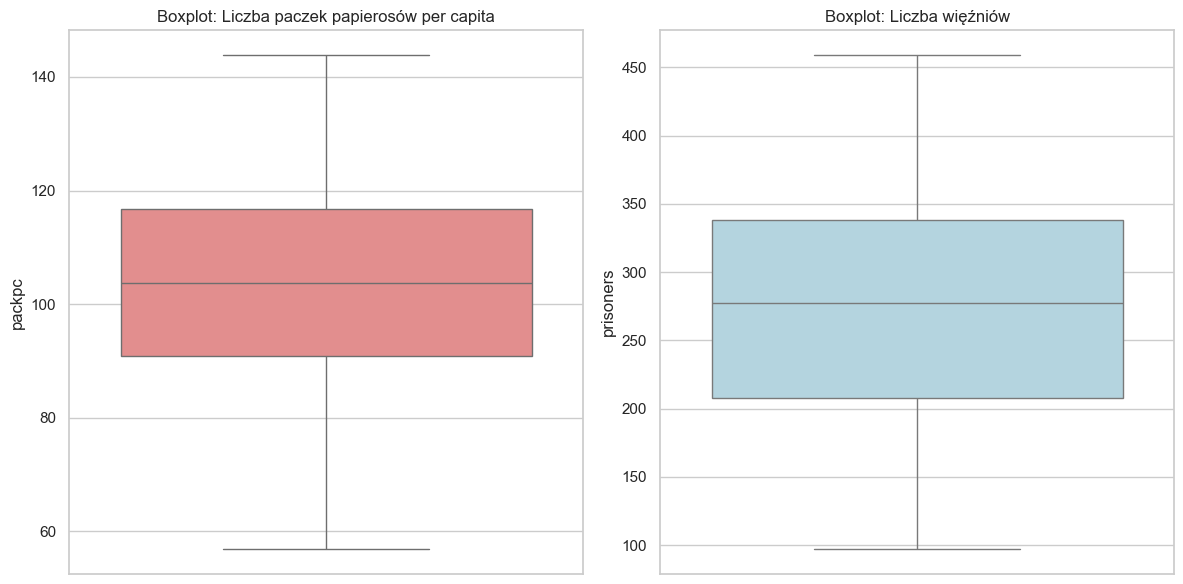

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie danych
cigarette = pd.read_csv("przyk/Cigarette10.csv", sep=';')
guns = pd.read_csv("przyk/Guns10.csv", sep=';')

# Usunięcie braków
packpc = cigarette['packpc'].dropna()
prisoners = guns['prisoners'].dropna()

# Styl
sns.set_style("whitegrid")

# Tworzenie dwóch boxplotów obok siebie
plt.figure(figsize=(12, 6))

# Boxplot dla paczek
plt.subplot(1, 2, 1)
sns.boxplot(y=packpc, color='lightcoral')
plt.title('Boxplot: Liczba paczek papierosów per capita')
plt.ylabel('packpc')

# Boxplot dla więźniów
plt.subplot(1, 2, 2)
sns.boxplot(y=prisoners, color='lightblue')
plt.title('Boxplot: Liczba więźniów')
plt.ylabel('prisoners')

plt.tight_layout()
plt.show()
